Aperçu des données :
   exam1_score  exam2_score  admitted
0    34.623660    78.024693         0
1    30.286711    43.894998         0
2    35.847409    72.902198         0
3    60.182599    86.308552         1
4    79.032736    75.344376         1

Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   exam1_score  100 non-null    float64
 1   exam2_score  100 non-null    float64
 2   admitted     100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Statistiques descriptives :
       exam1_score  exam2_score    admitted
count   100.000000   100.000000  100.000000
mean     65.644274    66.221998    0.600000
std      19.458222    18.582783    0.492366
min      30.058822    30.603263    0.000000
25%      50.919511    48.179205    0.000000
50%      67.032988    67.682381    1.000000
75%      80.212529    79.3

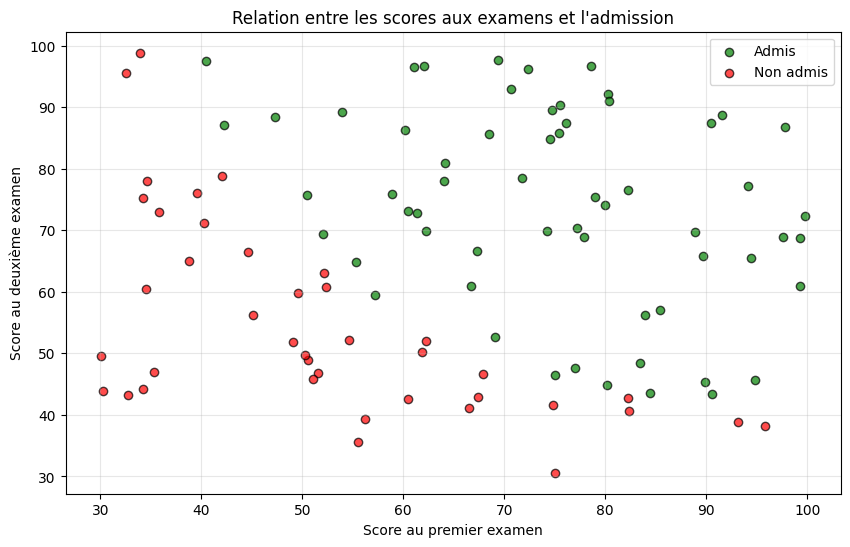


Coefficients (pentes) : [0.25970232 0.22481016]
Ordonnée à l'origine : -30.2000

Précision du modèle sur l'ensemble de test : 0.8000 (80.00%)


c:\Users\home\Desktop\DI-Bootcamp\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


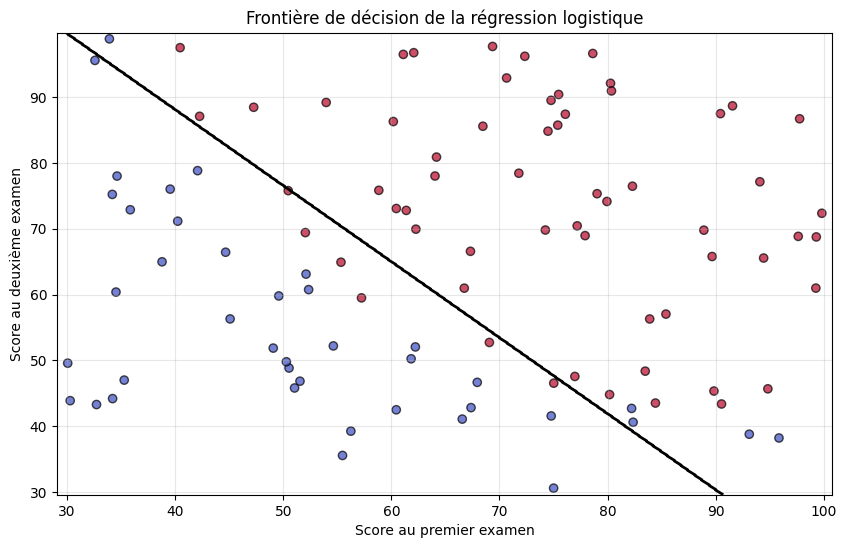


--- INTERPRÉTATION DES RÉSULTATS ---
Coefficient pour l'examen 1 : 0.2597
Coefficient pour l'examen 2 : 0.2248

Ces coefficients indiquent l'importance de chaque score d'examen
dans la prédiction d'admission. Un coefficient positif signifie
qu'un score plus élevé augmente la probabilité d'être admis.

 Le modèle a une bonne précision de 80.00%.

Le modèle de régression logistique est adapté à ce problème de classification binaire.
Il permet de prédire si un étudiant sera admis à l'université en fonction
de ses scores aux deux examens.


In [1]:
# Étape 1: Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Étape 2: Chargement du dataset depuis le lien GitHub
url = "https://raw.githubusercontent.com/kaleko/CourseraML/refs/heads/master/ex2/data/ex2data1.txt"
df = pd.read_csv(url, header=None, names=['exam1_score', 'exam2_score', 'admitted'])

# Étape 3: Exploration des données
print("Aperçu des données :")
print(df.head())
print("\nInformations sur le dataset :")
print(df.info())
print("\nStatistiques descriptives :")
print(df.describe())

# Étape 4: Création du scatter plot
plt.figure(figsize=(10, 6))
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]
plt.scatter(admitted['exam1_score'], admitted['exam2_score'],
            color='green', label='Admis', alpha=0.7, edgecolors='k')
plt.scatter(not_admitted['exam1_score'], not_admitted['exam2_score'],
            color='red', label='Non admis', alpha=0.7, edgecolors='k')
plt.xlabel('Score au premier examen')
plt.ylabel('Score au deuxième examen')
plt.title('Relation entre les scores aux examens et l\'admission')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Étape 5: Préparation des données pour le modèle
X = df[['exam1_score', 'exam2_score']]  # Caractéristiques (features)
y = df['admitted']                      # Cible (target)

# Étape 6: Division des données en entraînement et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Étape 7: Création et entraînement du modèle de régression logistique
model = LogisticRegression()
model.fit(X_train, y_train)

# Étape 8: Affichage des paramètres du modèle
print(f"\nCoefficients (pentes) : {model.coef_[0]}")
print(f"Ordonnée à l'origine : {model.intercept_[0]:.4f}")

# Étape 9: Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Étape 10: Calcul de la précision (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision du modèle sur l'ensemble de test : {accuracy:.4f} ({accuracy*100:.2f}%)")

# Étape 11: Prédictions sur l'ensemble complet
df['predicted'] = model.predict(X)

# Étape 12: Visualisation de la frontière de décision
plt.figure(figsize=(10, 6))
plt.scatter(df['exam1_score'], df['exam2_score'],
            c=df['admitted'], cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel('Score au premier examen')
plt.ylabel('Score au deuxième examen')
plt.title('Frontière de décision de la régression logistique')

# Création d'une grille pour tracer la frontière de décision
x1_min, x1_max = df['exam1_score'].min() - 1, df['exam1_score'].max() + 1
x2_min, x2_max = df['exam2_score'].min() - 1, df['exam2_score'].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1),
                       np.arange(x2_min, x2_max, 0.1))
Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)
plt.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)
plt.grid(True, alpha=0.3)
plt.show()

# Étape 13: Interprétation des résultats
print("\n--- INTERPRÉTATION DES RÉSULTATS ---")
print(f"Coefficient pour l'examen 1 : {model.coef_[0][0]:.4f}")
print(f"Coefficient pour l'examen 2 : {model.coef_[0][1]:.4f}")
print("\nCes coefficients indiquent l'importance de chaque score d'examen")
print("dans la prédiction d'admission. Un coefficient positif signifie")
print("qu'un score plus élevé augmente la probabilité d'être admis.")

if accuracy > 0.8:
    print(f"\n Le modèle a une excellente précision de {accuracy*100:.2f}%.")
elif accuracy > 0.6:
    print(f"\n Le modèle a une bonne précision de {accuracy*100:.2f}%.")
else:
    print(f"\n Le modèle a une précision modeste de {accuracy*100:.2f}%.")

print("\nLe modèle de régression logistique est adapté à ce problème de classification binaire.")
print("Il permet de prédire si un étudiant sera admis à l'université en fonction")
print("de ses scores aux deux examens.")